<h3 style="text-align: center;"> <strong> UNIVERSIDAD TECNOLÓGICA DE PANAMÁ </strong></h3>
<h3 style="text-align: center;">FACULTAD DE INGENIERÍA DE SISTEMAS COMPUTACIONALES</h3>
<h3 style="text-align: center;">DEPARTAMENTO DE COMPUTACIÓN Y SIMULACIÓN DE SISTEMAS</h3>
    
<h1 style="text-align: center;"><strong>-------LABORATORIO N°2:  Estadística y Probabilidad con Python-------</strong></h1>
<h3 style="text-align: center;">ANÁLISIS DE DATOS Y TOMA DE DECISIONES PARA COMPUTACIÓN - 1195</h3>




|  **FACILITADOR** | Dr. José Carlos Rangel Ortiz          |
|-----------------|---------------------------------------|
| **MÓDULO 1**    | Introducción a la Ciencia de Datos    |
|  **UNIDAD 1**    | CONCEPTOS BÁSICOS DE CIENCIA DE DATOS |
    

| **NOMBRE DEL ESTUDIANTE:** | ________________________________________________________________________________________|
|----------------------------|-----------------------------------------------------------------------------------------|
    


## Introducción al laboratorio

Este *notebook* se enfoca en el uso de libreías de Python para obtener información estadística de los datos y generar visulazaciones y resumenes de los mismos. En este laboratorio se probarán los diferentes metodos y códigos vistos durante clase. Abordaremos la temática de cargar nuestros datos a nuestro código fuente para obtener información estadística de un dataset. A su vez el desarrollo del laboratorio permitirá la aplicación de conceptos básicos para el manejo de datasets lo cual será de gran importancia en el desarrollo de la asignatura. Durante el laboratorio se solicitan diferentes agrupaciones y procesos con los datasets indicados. 

Como herramientas principales tendremos las siguientes:

* **Python** es un lenguaje de programación versátil que se ha convertido en una herramienta esencial para el análisis de datos. Su sintaxis simple y su amplia gama de bibliotecas lo hacen ideal para principiantes y expertos por igual.

* **Pandas** es una biblioteca de Python especializada en el análisis de datos. Ofrece una amplia gama de herramientas para trabajar con conjuntos de datos, desde la limpieza y la preparación de datos hasta el cálculo de estadísticas y la creación de gráficos.

En este laboratorio, te familiarizarás con los conceptos básicos de Python y Pandas, y aprenderás a utilizar estas herramientas para:

    - Leer y cargar conjuntos de datos desde diferentes fuentes, como archivos CSV y otras librerías.
    - Limpiar y preparar datos para su análisis, normalizando datos y filtrando datos.
    - Explorar datos utilizando técnicas de resumen estadístico y visualización de datos.
    - Crear gráficos informativos y atractivos para comunicar los resultados de tu análisis.

Al finalizar este laboratorio, habrás adquirido las habilidades básicas para trabajar con datos de manera efectiva utilizando Python y Pandas. Estas habilidades te serán útiles en una amplia gama de campos, incluyendo la investigación científica, el análisis de negocios, la ciencia de datos entre otros.

#### **Obs.** Consulte también el Notebook **08_Pandas_CSV.ipynb**, disponible es los ejemplos de Python que se encuentran en el Moodle.

# Problemas propuestos

# Dataset Wine de SKLearn

Utilizando el dataset Wine (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine) disponible en SKLearn realice las siguientes operaciones.

# **[1]**  Cargue el Dataset en el Notebook
## Recuerde convertir el resultado de la carga del dataset a un DataFrame de Pandas

In [25]:
import os
import sys
import urllib.error
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.datasets import load_wine


def lab2_csv_path(filename: str) -> Path:
    """Busca el CSV en el repo local; si no existe (p. ej. Colab en /content), lo descarga del curso en GitHub."""
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in (base / "labs" / "Lab2" / filename, base / filename):
            if candidate.is_file():
                return candidate

    env_dir = os.environ.get("LAB2_DATA_DIR")
    if env_dir:
        env_path = Path(env_dir) / filename
        if env_path.is_file():
            return env_path

    if os.environ.get("LAB2_CACHE_DIR"):
        cache_dir = Path(os.environ["LAB2_CACHE_DIR"])
    elif "google.colab" in sys.modules:
        cache_dir = Path("/content/lab2_data")
    else:
        cache_dir = Path.home() / ".cache" / "lab2_csv"
    cache_dir.mkdir(parents=True, exist_ok=True)
    dest = cache_dir / filename
    if dest.is_file():
        return dest

    base_url = os.environ.get(
        "LAB2_REPO_BASE_URL",
        "https://raw.githubusercontent.com/Quantumquirkz/Data-Science---Engineer---Analytics/main/labs/Lab2",
    )
    url = f"{base_url.rstrip('/')}/{filename}"
    print(f"Descargando {filename}…\n  {url}")
    try:
        urllib.request.urlretrieve(url, dest)
    except urllib.error.HTTPError as e:
        raise FileNotFoundError(
            f"No hay copia local de {filename} y la descarga falló (HTTP {e.code}): {url}"
        ) from e
    except urllib.error.URLError as e:
        raise FileNotFoundError(
            f"No hay copia local de {filename} y falló la red: {e.reason!r}"
        ) from e
    return dest


sns.set_theme(style="whitegrid")
%matplotlib inline

wine = load_wine(as_frame=True)
df_wine = wine.frame.copy()
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# **[2]**  Obtenga los detalles del dataset

In [26]:
print("Dimensiones (filas, columnas):", df_wine.shape)
print("\nNombres de columnas:\n", df_wine.columns.tolist())
print("\ninfo():")
df_wine.info()
print("\ndescribe():")
display(df_wine.describe())
print("\nPrimeras filas:")
display(df_wine.head())

Dimensiones (filas, columnas): (178, 14)

Nombres de columnas:
 ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']

info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanth

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000



Primeras filas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# **[3]**  Obtenga la Mediana de la columna 1,3,11
Obs. Utilice esos índices concretamente

In [27]:
# Índices de columna 1, 3 y 11 (iloc, base 0)
medianas = df_wine.iloc[:, [1, 3, 11]].median()
print("Mediana columna 1:", medianas.iloc[0])
print("Mediana columna 3:", medianas.iloc[1])
print("Mediana columna 11:", medianas.iloc[2])
print("\nResumen:")
medianas

Mediana columna 1: 1.8650000000000002
Mediana columna 3: 19.5
Mediana columna 11: 2.78

Resumen:


,0
malic_acid,1.865
alcalinity_of_ash,19.500
od280/od315_of_diluted_wines,2.780


# **[4]**  Indique la cantidad de columnas del dataset

In [28]:
n_columnas = df_wine.shape[1]
print(f"Cantidad de columnas del dataset Wine: {n_columnas}")

Cantidad de columnas del dataset Wine: 14


# **[5]**  Genere un digarama de caja y bigote para la columna 7 

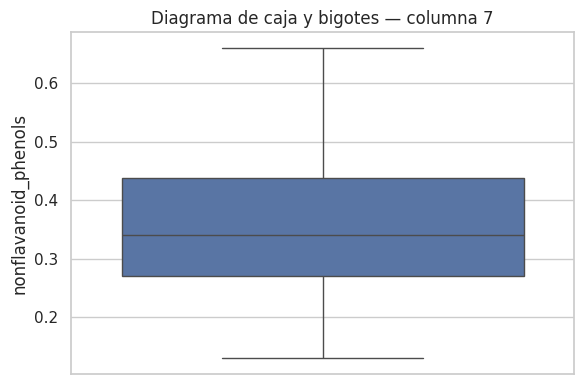

In [29]:
col7 = df_wine.iloc[:, 7]
plt.figure(figsize=(6, 4))
sns.boxplot(y=col7)
plt.ylabel(df_wine.columns[7])
plt.title("Diagrama de caja y bigotes — columna 7")
plt.tight_layout()
plt.show()

# **[6]**  Genere un digarama de caja y bigote para la columna  9

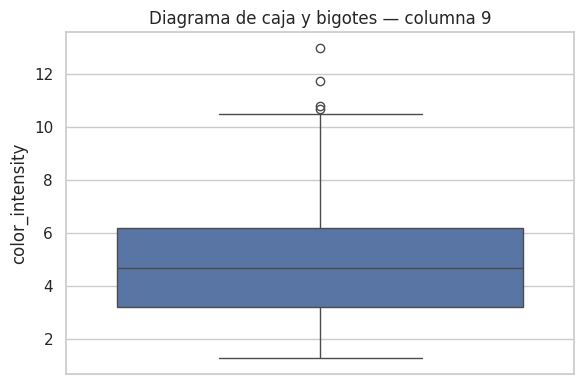

In [30]:
col9 = df_wine.iloc[:, 9]
plt.figure(figsize=(6, 4))
sns.boxplot(y=col9)
plt.ylabel(df_wine.columns[9])
plt.title("Diagrama de caja y bigotes — columna 9")
plt.tight_layout()
plt.show()

# **[7]**  Indique cual es el delimitador de outliers para la columna 9 

In [31]:
# Límites del bigote en un boxplot clásico: Q1 - 1.5*IQR y Q3 + 1.5*IQR
serie = df_wine.iloc[:, 9]
q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
print(f"Columna: {df_wine.columns[9]}")
print(f"Q1 = {q1:.4f}, Q3 = {q3:.4f}, IQR = {iqr:.4f}")
print(f"Delimitador inferior de outliers (bigote): {limite_inferior:.4f}")
print(f"Delimitador superior de outliers (bigote): {limite_superior:.4f}")

Columna: color_intensity
Q1 = 3.2200, Q3 = 6.2000, IQR = 2.9800
Delimitador inferior de outliers (bigote): -1.2500
Delimitador superior de outliers (bigote): 10.6700


# **[8]**  Genere un histograma de frecuencia para la columna 9

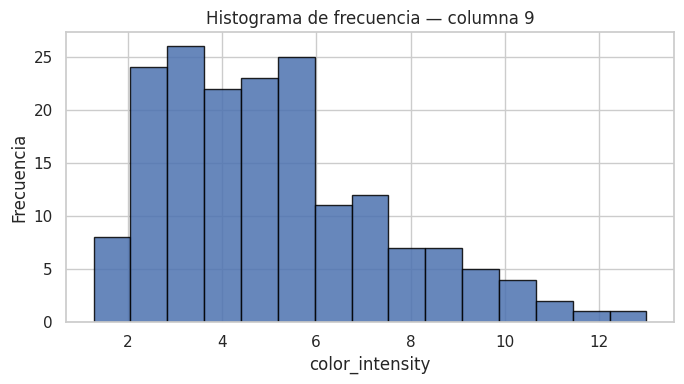

In [32]:
plt.figure(figsize=(7, 4))
plt.hist(df_wine.iloc[:, 9], bins=15, edgecolor="black", alpha=0.85)
plt.xlabel(df_wine.columns[9])
plt.ylabel("Frecuencia")
plt.title("Histograma de frecuencia — columna 9")
plt.tight_layout()
plt.show()

# **[9]**  Genere un histograma y diagrama de densidad para la columna 9 

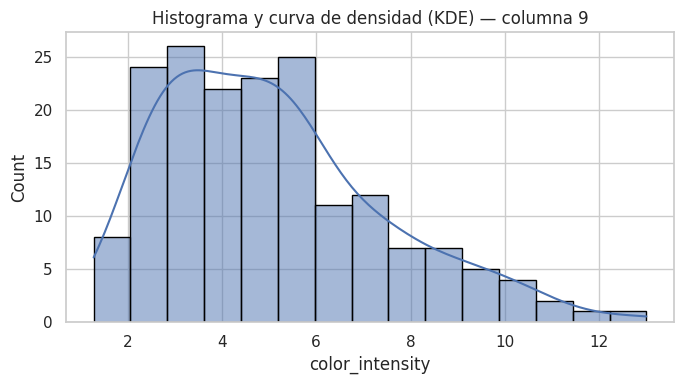

In [33]:
plt.figure(figsize=(7, 4))
sns.histplot(df_wine.iloc[:, 9], kde=True, bins=15, edgecolor="black")
plt.xlabel(df_wine.columns[9])
plt.title("Histograma y curva de densidad (KDE) — columna 9")
plt.tight_layout()
plt.show()

# **[10]**  Diagrama de Densidad para la columna 9

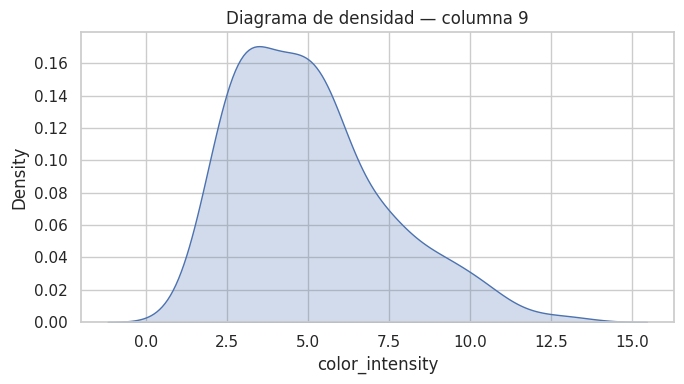

In [34]:
plt.figure(figsize=(7, 4))
sns.kdeplot(df_wine.iloc[:, 9], fill=True)
plt.xlabel(df_wine.columns[9])
plt.title("Diagrama de densidad — columna 9")
plt.tight_layout()
plt.show()

# **[11]**  Aplique el Escalado Z a la columna 2 y grafique el antes y despues

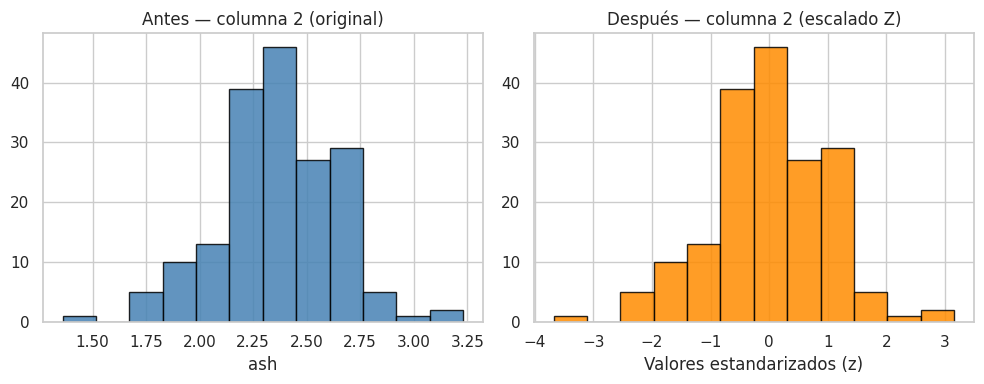

In [35]:
col2 = df_wine.iloc[:, 2]
col2_z = (col2 - col2.mean()) / col2.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(col2, bins=12, edgecolor="black", alpha=0.85, color="steelblue")
axes[0].set_title("Antes — columna 2 (original)")
axes[0].set_xlabel(df_wine.columns[2])

axes[1].hist(col2_z, bins=12, edgecolor="black", alpha=0.85, color="darkorange")
axes[1].set_title("Después — columna 2 (escalado Z)")
axes[1].set_xlabel("Valores estandarizados (z)")

plt.tight_layout()
plt.show()

# Dataset 2

## UCI Heart Disease 

https://www.kaggle.com/datasets/rcratos/heart-disease-data-compiled-from-uci

## Nombre del Archivo "UCI_Heart_Disease_Dataset_Combined.csv"

# **[12]**  Obtenga los detalles del dataset

In [36]:
df_heart = pd.read_csv(lab2_csv_path("UCI_Heart_Disease_Dataset_Combined.csv"))
print("Dimensiones:", df_heart.shape)
print("\nColumnas:", df_heart.columns.tolist())
df_heart.info()
display(df_heart.describe(include="all"))
display(df_heart.head())

Descargando UCI_Heart_Disease_Dataset_Combined.csv…
  https://raw.githubusercontent.com/Quantumquirkz/Data-Science---Engineer---Analytics/main/labs/Lab2/UCI_Heart_Disease_Dataset_Combined.csv
Dimensiones: (2943, 11)

Columnas: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2943 entries, 0 to 2942
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             2943 non-null   int64  
 1   Sex             2943 non-null   int64  
 2   ChestPainType   2943 non-null   int64  
 3   RestingBP       2943 non-null   int64  
 4   Cholesterol     2943 non-null   int64  
 5   FastingBS       2943 non-null   int64  
 6   RestingECG      2943 non-null   int64  
 7   MaxHR           2943 non-null   int64  
 8   ExerciseAngina  2943 non-null   int64  
 9   Oldpeak         2943 non-

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000
mean,52.381923,0.748556,1.363575,138.698267,253.515121,0.225280,0.626911,144.040095,0.412504,1.570031,0.548420
std,13.037189,0.433917,1.142614,24.623198,112.724716,0.417838,0.713650,28.446327,0.492369,1.585102,0.497735
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,44.000000,0.000000,0.000000,120.500000,204.000000,0.000000,0.000000,124.000000,0.000000,0.100000,0.000000
50%,54.000000,1.000000,1.000000,134.000000,248.000000,0.000000,0.000000,145.000000,0.000000,1.200000,1.000000
75%,61.000000,1.000000,2.000000,150.000000,306.000000,0.000000,1.000000,165.000000,1.000000,2.400000,1.000000
max,80.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,1.000000


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,1,1,140,289,0,0,172,0,0.0,0
1,49,0,2,160,180,0,0,156,0,1.0,1
2,37,1,1,130,283,0,1,98,0,0.0,0
3,48,0,3,138,214,0,0,108,1,1.5,1
4,54,1,2,150,195,0,0,122,0,0.0,0


# **[13]**  Diagrama de Densidad para el colesterol

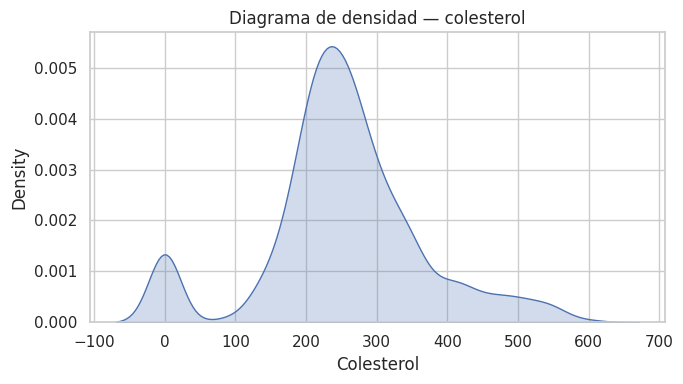

In [37]:
plt.figure(figsize=(7, 4))
sns.kdeplot(df_heart["Cholesterol"], fill=True)
plt.xlabel("Colesterol")
plt.title("Diagrama de densidad — colesterol")
plt.tight_layout()
plt.show()

# **[14]**  Genere un digarama de caja y bigote para la columna Colesterol

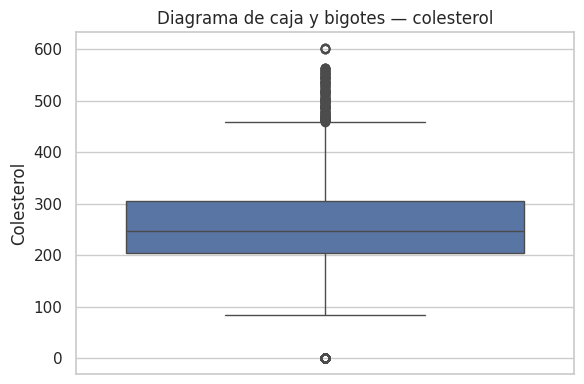

In [38]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_heart["Cholesterol"])
plt.ylabel("Colesterol")
plt.title("Diagrama de caja y bigotes — colesterol")
plt.tight_layout()
plt.show()

# **[15]** IQR para la calumna RestingBP

In [39]:
rbp = df_heart["RestingBP"]
q1 = rbp.quantile(0.25)
q3 = rbp.quantile(0.75)
iqr = q3 - q1
print("RestingBP — IQR = Q3 - Q1")
print(f"Q1 = {q1:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")

RestingBP — IQR = Q3 - Q1
Q1 = 120.50
Q3 = 150.00
IQR = 29.50


# **[16]**  Usando *{df_name}.dtypes* indique el tipo de cada columna

In [40]:
print("Tipos de dato por columna (df_heart.dtypes):")
df_heart.dtypes

Tipos de dato por columna (df_heart.dtypes):


,0
Age,int64
Sex,int64
ChestPainType,int64
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64


# **[17]**  Convierta la Columna HeartDisease y Sex a tipo categórica

In [41]:
df_heart["HeartDisease"] = df_heart["HeartDisease"].astype("category")
df_heart["Sex"] = df_heart["Sex"].astype("category")
print("Conversiones aplicadas: HeartDisease y Sex → categóricas.")

Conversiones aplicadas: HeartDisease y Sex → categóricas.


# **[18]**  Usando {df_name.column_name}.dtypes indique el tipo de dato de la columna Sex

In [42]:
# En pandas, una Serie tiene .dtype (singular). El enunciado cita .dtypes;
# para una columna concreta se usa:
print(df_heart["Sex"].dtype)

category


# **[19]**  Indique para la Columna Sex cuales son los valores diponibles y su significado

In [43]:
print("Categorías en Sex:", df_heart["Sex"].cat.categories.tolist())
print("\nSignificado habitual en compilaciones UCI de enfermedad cardíaca:")
print("  • 0 → Femenino")
print("  • 1 → Masculino")
print("\nConteo por categoría (antes de renombrar a M/F):")
print(df_heart["Sex"].value_counts().sort_index())

Categorías en Sex: [0, 1]

Significado habitual en compilaciones UCI de enfermedad cardíaca:
  • 0 → Femenino
  • 1 → Masculino

Conteo por categoría (antes de renombrar a M/F):
Sex
0     740
1    2203
Name: count, dtype: int64


# **[20]**  Cambie en el dataset los valores de la columna Sex por las letras M y F. 

In [44]:
df_heart["Sex"] = df_heart["Sex"].map({0: "F", 1: "M"}).astype("category")
print(df_heart["Sex"].value_counts())
df_heart.head()

Sex
M    2203
F     740
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,M,1,140,289,0,0,172,0,0.0,0
1,49,F,2,160,180,0,0,156,0,1.0,1
2,37,M,1,130,283,0,1,98,0,0.0,0
3,48,F,3,138,214,0,0,108,1,1.5,1
4,54,M,2,150,195,0,0,122,0,0.0,0


# **[21]** Presente el conteo de elementos agrupados por la columna HeartDisease

In [45]:
conteo_hd = df_heart["HeartDisease"].value_counts().sort_index()
print("Conteo por HeartDisease:")
print(conteo_hd)

Conteo por HeartDisease:
HeartDisease
0    1329
1    1614
Name: count, dtype: int64


# **[22]** Presente un crosstab usando las columnas Sex y HeartDisease

In [46]:
ct_sex_hd = pd.crosstab(df_heart["Sex"], df_heart["HeartDisease"])
print("Crosstab Sex × HeartDisease:")
display(ct_sex_hd)

Crosstab Sex × HeartDisease:


HeartDisease,0,1
Sex,,
F,331,409
M,998,1205


# **[23]** Utilizando group by para las columnas Sex y HeartDisease presente el conteo según cada categoría

In [47]:
gb = df_heart.groupby(["Sex", "HeartDisease"], observed=True).size()
print("Conteo por Sex y HeartDisease (groupby):")
print(gb)

Conteo por Sex y HeartDisease (groupby):
Sex  HeartDisease
F    0                331
     1                409
M    0                998
     1               1205
dtype: int64


# **[24]** Utilizando el *plot.bar* presente una gráfica del crosstab realizado entre Sex y HeartDisease

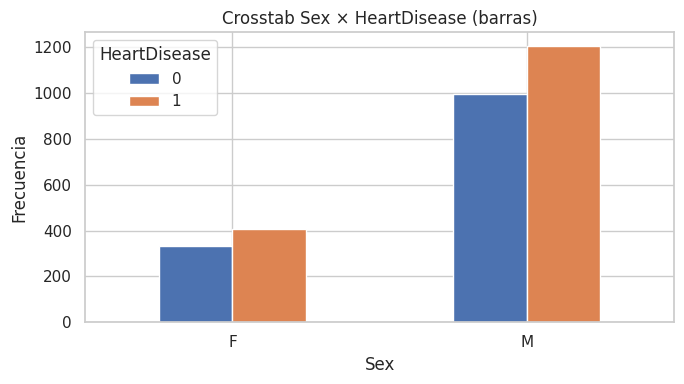

In [48]:
ax = ct_sex_hd.plot.bar(figsize=(7, 4), rot=0)
plt.ylabel("Frecuencia")
plt.title("Crosstab Sex × HeartDisease (barras)")
plt.tight_layout()
plt.show()

# Dataset 3
## Retail Sales Analysis Dataset
https://www.kaggle.com/datasets/sahirmaharajj/retail-sales-analysis/data

# **[25]** Leer archivo CSV
### Nombre del archivo "Warehouse_and_Retail_Sales.csv"

In [49]:
df_retail = pd.read_csv(lab2_csv_path("Warehouse_and_Retail_Sales.csv"))
df_retail.head()

Descargando Warehouse_and_Retail_Sales.csv…
  https://raw.githubusercontent.com/Quantumquirkz/Data-Science---Engineer---Analytics/main/labs/Lab2/Warehouse_and_Retail_Sales.csv


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


# **[26]** Descripción del Dataset

In [50]:
print("Dimensiones:", df_retail.shape)
df_retail.info()
display(df_retail.describe(include="all"))

Dimensiones: (307645, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307478,307645,307645,307644,307642.000000,307645.000000,307645.000000
unique,NaN,NaN,396,34056,34822,8,NaN,NaN,NaN
top,NaN,NaN,REPUBLIC NATIONAL DISTRIBUTING CO,10269,BURGANS ALBARINO - 750ML,WINE,NaN,NaN,NaN
freq,NaN,NaN,20995,24,44,187640,NaN,NaN,NaN
mean,2018.438525,6.423862,NaN,NaN,NaN,NaN,7.024071,6.936465,25.294597
std,1.083061,3.461812,NaN,NaN,NaN,NaN,30.986238,30.237195,249.916798
min,2017.000000,1.000000,NaN,NaN,NaN,NaN,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,NaN,NaN,NaN,NaN,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,NaN,NaN,NaN,NaN,3.267500,3.000000,5.000000


# **[27]** Indique los tipos de las columnas del dataset

In [51]:
print("Tipos de columna (df_retail.dtypes):")
df_retail.dtypes

Tipos de columna (df_retail.dtypes):


,0
YEAR,int64
MONTH,int64
SUPPLIER,object
ITEM CODE,object
ITEM DESCRIPTION,object
ITEM TYPE,object
RETAIL SALES,float64
RETAIL TRANSFERS,float64
WAREHOUSE SALES,float64


# **[28]** Determine la cantidad de SUPPLIERS diferentes en el dataset

In [52]:
n_suppliers = df_retail["SUPPLIER"].nunique()
print(f"Cantidad de proveedores (SUPPLIERS) distintos: {n_suppliers}")

Cantidad de proveedores (SUPPLIERS) distintos: 396


# **[29]** Indique la cantidad de instancias en el dataset 

In [53]:
n_filas = len(df_retail)
print(f"Cantidad de instancias (filas) en el dataset: {n_filas}")

Cantidad de instancias (filas) en el dataset: 307645


# **[30]** Imprima cúales son los tipos de items (columna 'ITEM TYPE') disponibles en el dataset

In [54]:
tipos_item = df_retail["ITEM TYPE"].dropna().unique()
print("Tipos de ítem disponibles (ITEM TYPE):")
print(sorted(tipos_item))
n_sin_tipo = df_retail["ITEM TYPE"].isna().sum()
if n_sin_tipo:
    print(f"(Filas sin ITEM TYPE excluidas del listado: {n_sin_tipo})")

Tipos de ítem disponibles (ITEM TYPE):


TypeError: '<' not supported between instances of 'float' and 'str'

# **[31]** Obtenga el conteo de las columnas, agrupandolas mediante el Tipo de Item, el mes y el año de venta

In [ ]:
conteo_grupo = (
    df_retail.groupby(["ITEM TYPE", "MONTH", "YEAR"], observed=False)
    .size()
    .rename("conteo")
)
print("Conteo de registros por tipo de ítem, mes y año (primeras filas):")
display(conteo_grupo.head(15))
print(f"\nTotal de combinaciones (grupos): {len(conteo_grupo)}")

# **[32]** Cree un extracto del dataset que contenga solo la información para el item BEER
## Imprima la cantidad de valores de este dataset

In [ ]:
df_beer = df_retail[df_retail["ITEM TYPE"] == "BEER"].copy()
print(f"Cantidad de filas en el extracto BEER: {len(df_beer)}")
df_beer.head()

# **[33]** Cambie en este dataset el tipo de dato de la columna mes y año a categórica

In [ ]:
df_beer["MONTH"] = df_beer["MONTH"].astype("category")
df_beer["YEAR"] = df_beer["YEAR"].astype("category")
print(df_beer[["MONTH", "YEAR"]].dtypes)

# **[34]** Cambie en el dataset los valores de la columna MONTH por una abreviatura de los respectivos meses 

In [ ]:
import calendar

mes_num = pd.to_numeric(df_beer["MONTH"], errors="coerce").astype(int)
df_beer["MONTH"] = mes_num.map(lambda m: calendar.month_abbr[m]).astype("category")
print(df_beer["MONTH"].cat.categories.tolist())
df_beer.head()

# **[35]** Presente un gráfico de barras de un crosstab entre el mes y el año

In [ ]:
ct_mes_anio = pd.crosstab(df_beer["MONTH"], df_beer["YEAR"])
ax = ct_mes_anio.plot.bar(figsize=(12, 5), width=0.85)
plt.ylabel("Frecuencia")
plt.xlabel("Mes")
plt.title("Crosstab mes × año (extracto BEER)")
plt.legend(title="Año", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# **[36]** Presente un gráfico de barras de un crosstab entre el año y el mes

In [ ]:
ct_anio_mes = pd.crosstab(df_beer["YEAR"], df_beer["MONTH"])
ax = ct_anio_mes.plot.bar(figsize=(14, 5), width=0.85, rot=0)
plt.ylabel("Frecuencia")
plt.xlabel("Año")
plt.title("Crosstab año × mes (extracto BEER)")
plt.legend(title="Mes", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

# **[37]** Conclusiones

**Conclusiones (completar y ajustar según los resultados obtenidos al ejecutar el notebook):**

1. **Dataset Wine (sklearn):** Se cargó como `DataFrame` de pandas; las medianas en las columnas con índices 1, 3 y 11 resumen la tendencia central de esas variables químicas. Los diagramas de caja permiten ver asimetrías y valores atípicos; para la columna 9, los bigotes del boxplot siguen la regla de Tukey (límites en \(Q1 - 1.5 \times \mathrm{IQR}\) y \(Q3 + 1.5 \times \mathrm{IQR}\)). El escalado Z en la columna 2 conserva la forma de la distribución pero centra y escala los valores, útil para comparar variables en distintas escalas.

2. **UCI Heart Disease:** El colesterol y la presión en reposo muestran dispersión relevante; el IQR de `RestingBP` cuantifica la variabilidad central. Convertir `HeartDisease` y `Sex` a categóricas facilita agregaciones y tablas cruzadas; el reemplazo 0/1 por F/M aclara la interpretación. Los cruces Sex × HeartDisease muestran cómo se distribuye la presencia de enfermedad entre grupos.

3. **Retail:** El archivo combina ventas por proveedor, ítem y tiempo; el conteo por tipo de ítem, mes y año resume el volumen de registros por celda temporal. El subconjunto BEER reduce el análisis a una categoría; las gráficas de crosstab mes–año y año–mes enfatizan distintas vistas de la misma tabla de frecuencias.

4. **Pandas y visualización:** `describe`, `info`, `groupby`, `crosstab` y gráficos de seaborn/matplotlib son suficientes para un primer perfilado exploratorio antes de modelado o decisiones de negocio.